In [1]:
import sbibm
import matplotlib.pyplot as plt
import os.path

import torch

In [2]:
def load_data(data_path):
    data = torch.load(data_path, map_location=torch.device("cpu"))
    model_num = len(data)
    task_name = data[0]["task"]
    task = sbibm.get_task(task_name)
    obs_num = 10
    theta_num = task.dim_parameters

    est_sigma2 = torch.zeros(model_num, obs_num, theta_num)
    est_mu = torch.zeros(model_num, obs_num, theta_num)
    true_mu = torch.zeros(model_num, obs_num, theta_num)

    for i in range(model_num):
        test_dict_list = data[i]["test_dict_list"]
        for obs_index in range(obs_num):
            est_mu[i, obs_index] = test_dict_list[obs_index]["est_mu"]
            est_sigma2[i, obs_index] = test_dict_list[obs_index]["est_sigma2"]
            true_mu[i, obs_index] = test_dict_list[obs_index]["true_mu"]
    return {
        "task_name": task_name,
        "obs_num": obs_num,
        "theta_num": theta_num,
        "est_mu": est_mu,
        "est_sigma2": est_sigma2,
        "true_mu": true_mu,
    }

In [3]:
def plot_data(data_path, elbo_data_path):
    if not os.path.isfile(data_path):
        print(f"skip {data_path}")
        return None
    
    data_dict = load_data(data_path)
    obs_num = data_dict["obs_num"]
    theta_num = data_dict["theta_num"]
    est_mu = data_dict["est_mu"]
    true_mu = data_dict["true_mu"]
    task_name: str = data_dict["task_name"]

    elbo_data_found = False
    if not os.path.isfile(elbo_data_path):
        print(f"skip {elbo_data_path}")
    else:
        elbo_data_dict = load_data(elbo_data_path)
        elbo_est_mu = elbo_data_dict["est_mu"]
        elbo_data_found = True

    fig, axes = plt.subplots(theta_num, obs_num, 
                             figsize=(obs_num * 2, theta_num * 2),
                             constrained_layout=True)
    
    axes: list[plt.Axes] = axes.flatten()
    for i, ax in enumerate(axes):
        ri, ci = i % obs_num, i // obs_num
        if elbo_data_found:
            ax.boxplot([est_mu[:, ri, ci], 
                        elbo_est_mu[:, ri, ci]],
                        labels=["FAVI", "ELBO"])
        else:
            ax.boxplot(est_mu[:, ri, ci],
                       labels=["FAVI", ])
        ax.axhline(y=true_mu[:, ri, ci].mean().item(), 
                color="r", linestyle="--", linewidth=1)
        ax.set_title(f"obs {ri}; theta {ci}")
    
    fig.suptitle(task_name.replace("_", " ").upper(), 
                 fontsize=12)
    fig.show()

In [4]:
sbibm.get_available_tasks()

['sir',
 'two_moons',
 'slcp',
 'gaussian_linear_uniform',
 'lotka_volterra',
 'bernoulli_glm',
 'gaussian_mixture',
 'gaussian_linear',
 'slcp_distractors',
 'bernoulli_glm_raw']

In [5]:
task_list = [t for t in sbibm.get_available_tasks() if t not in ["sir", "lotka_volterra"]]

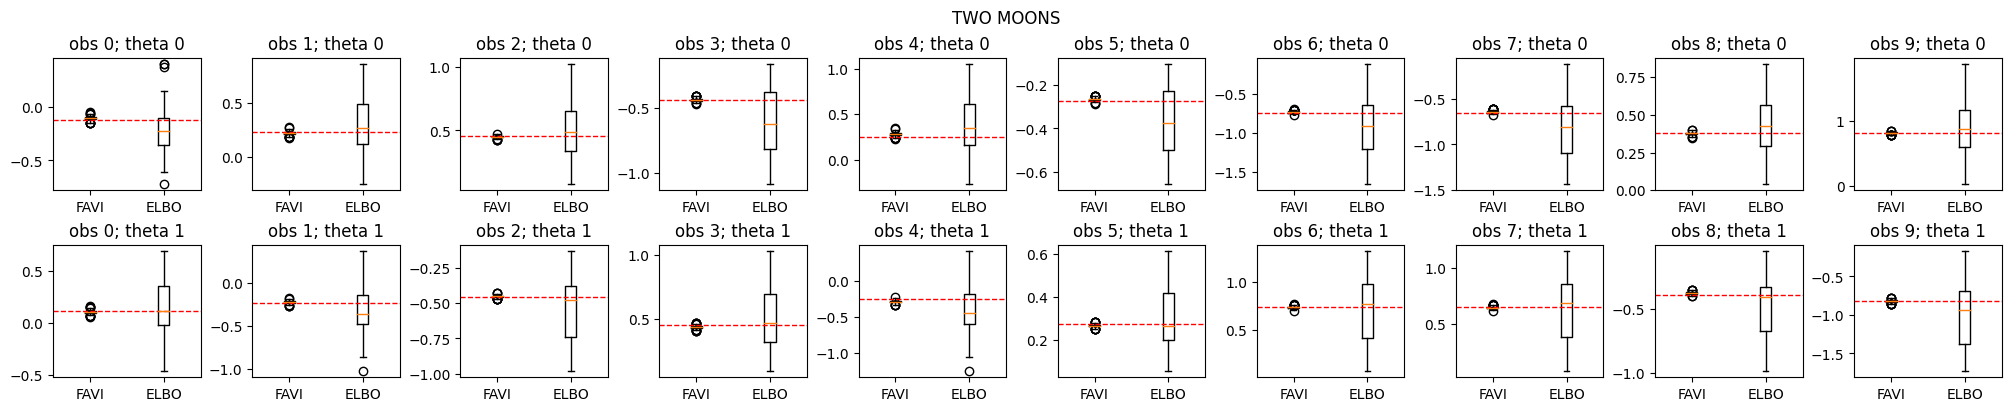

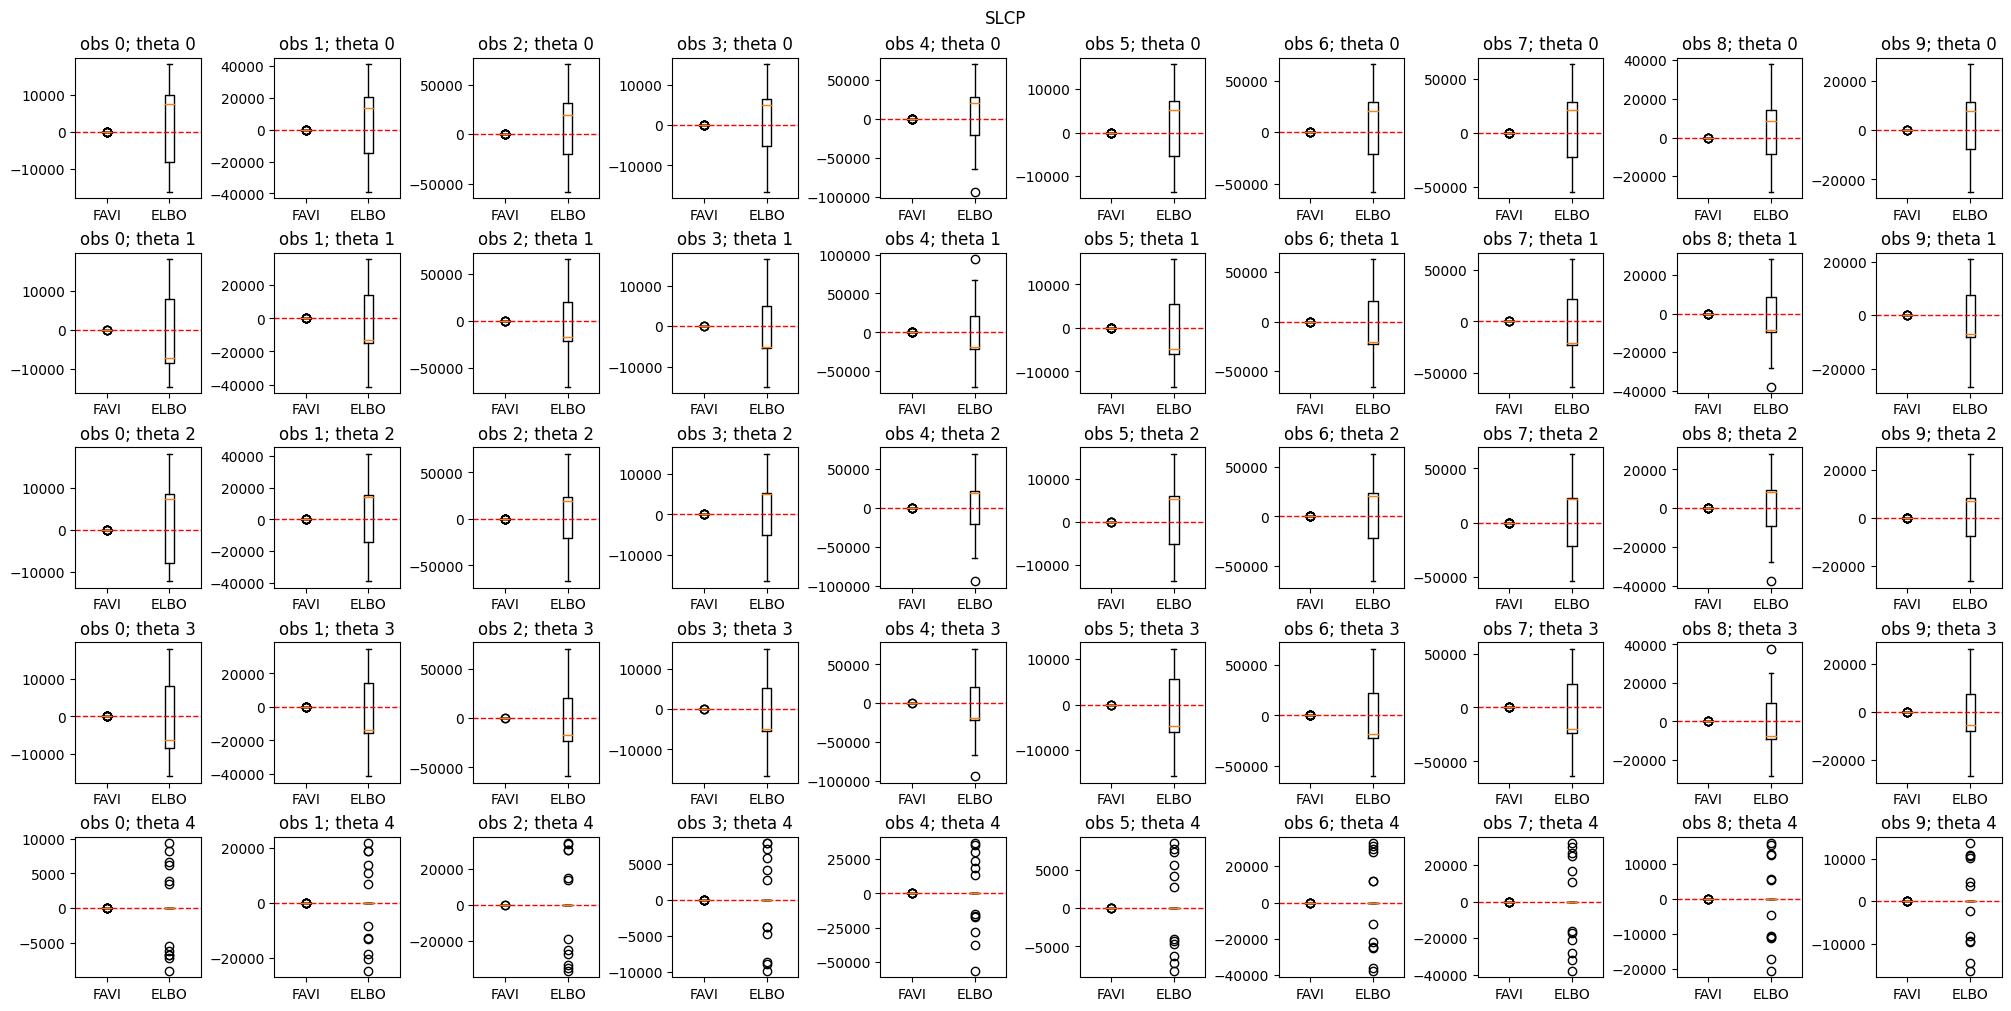

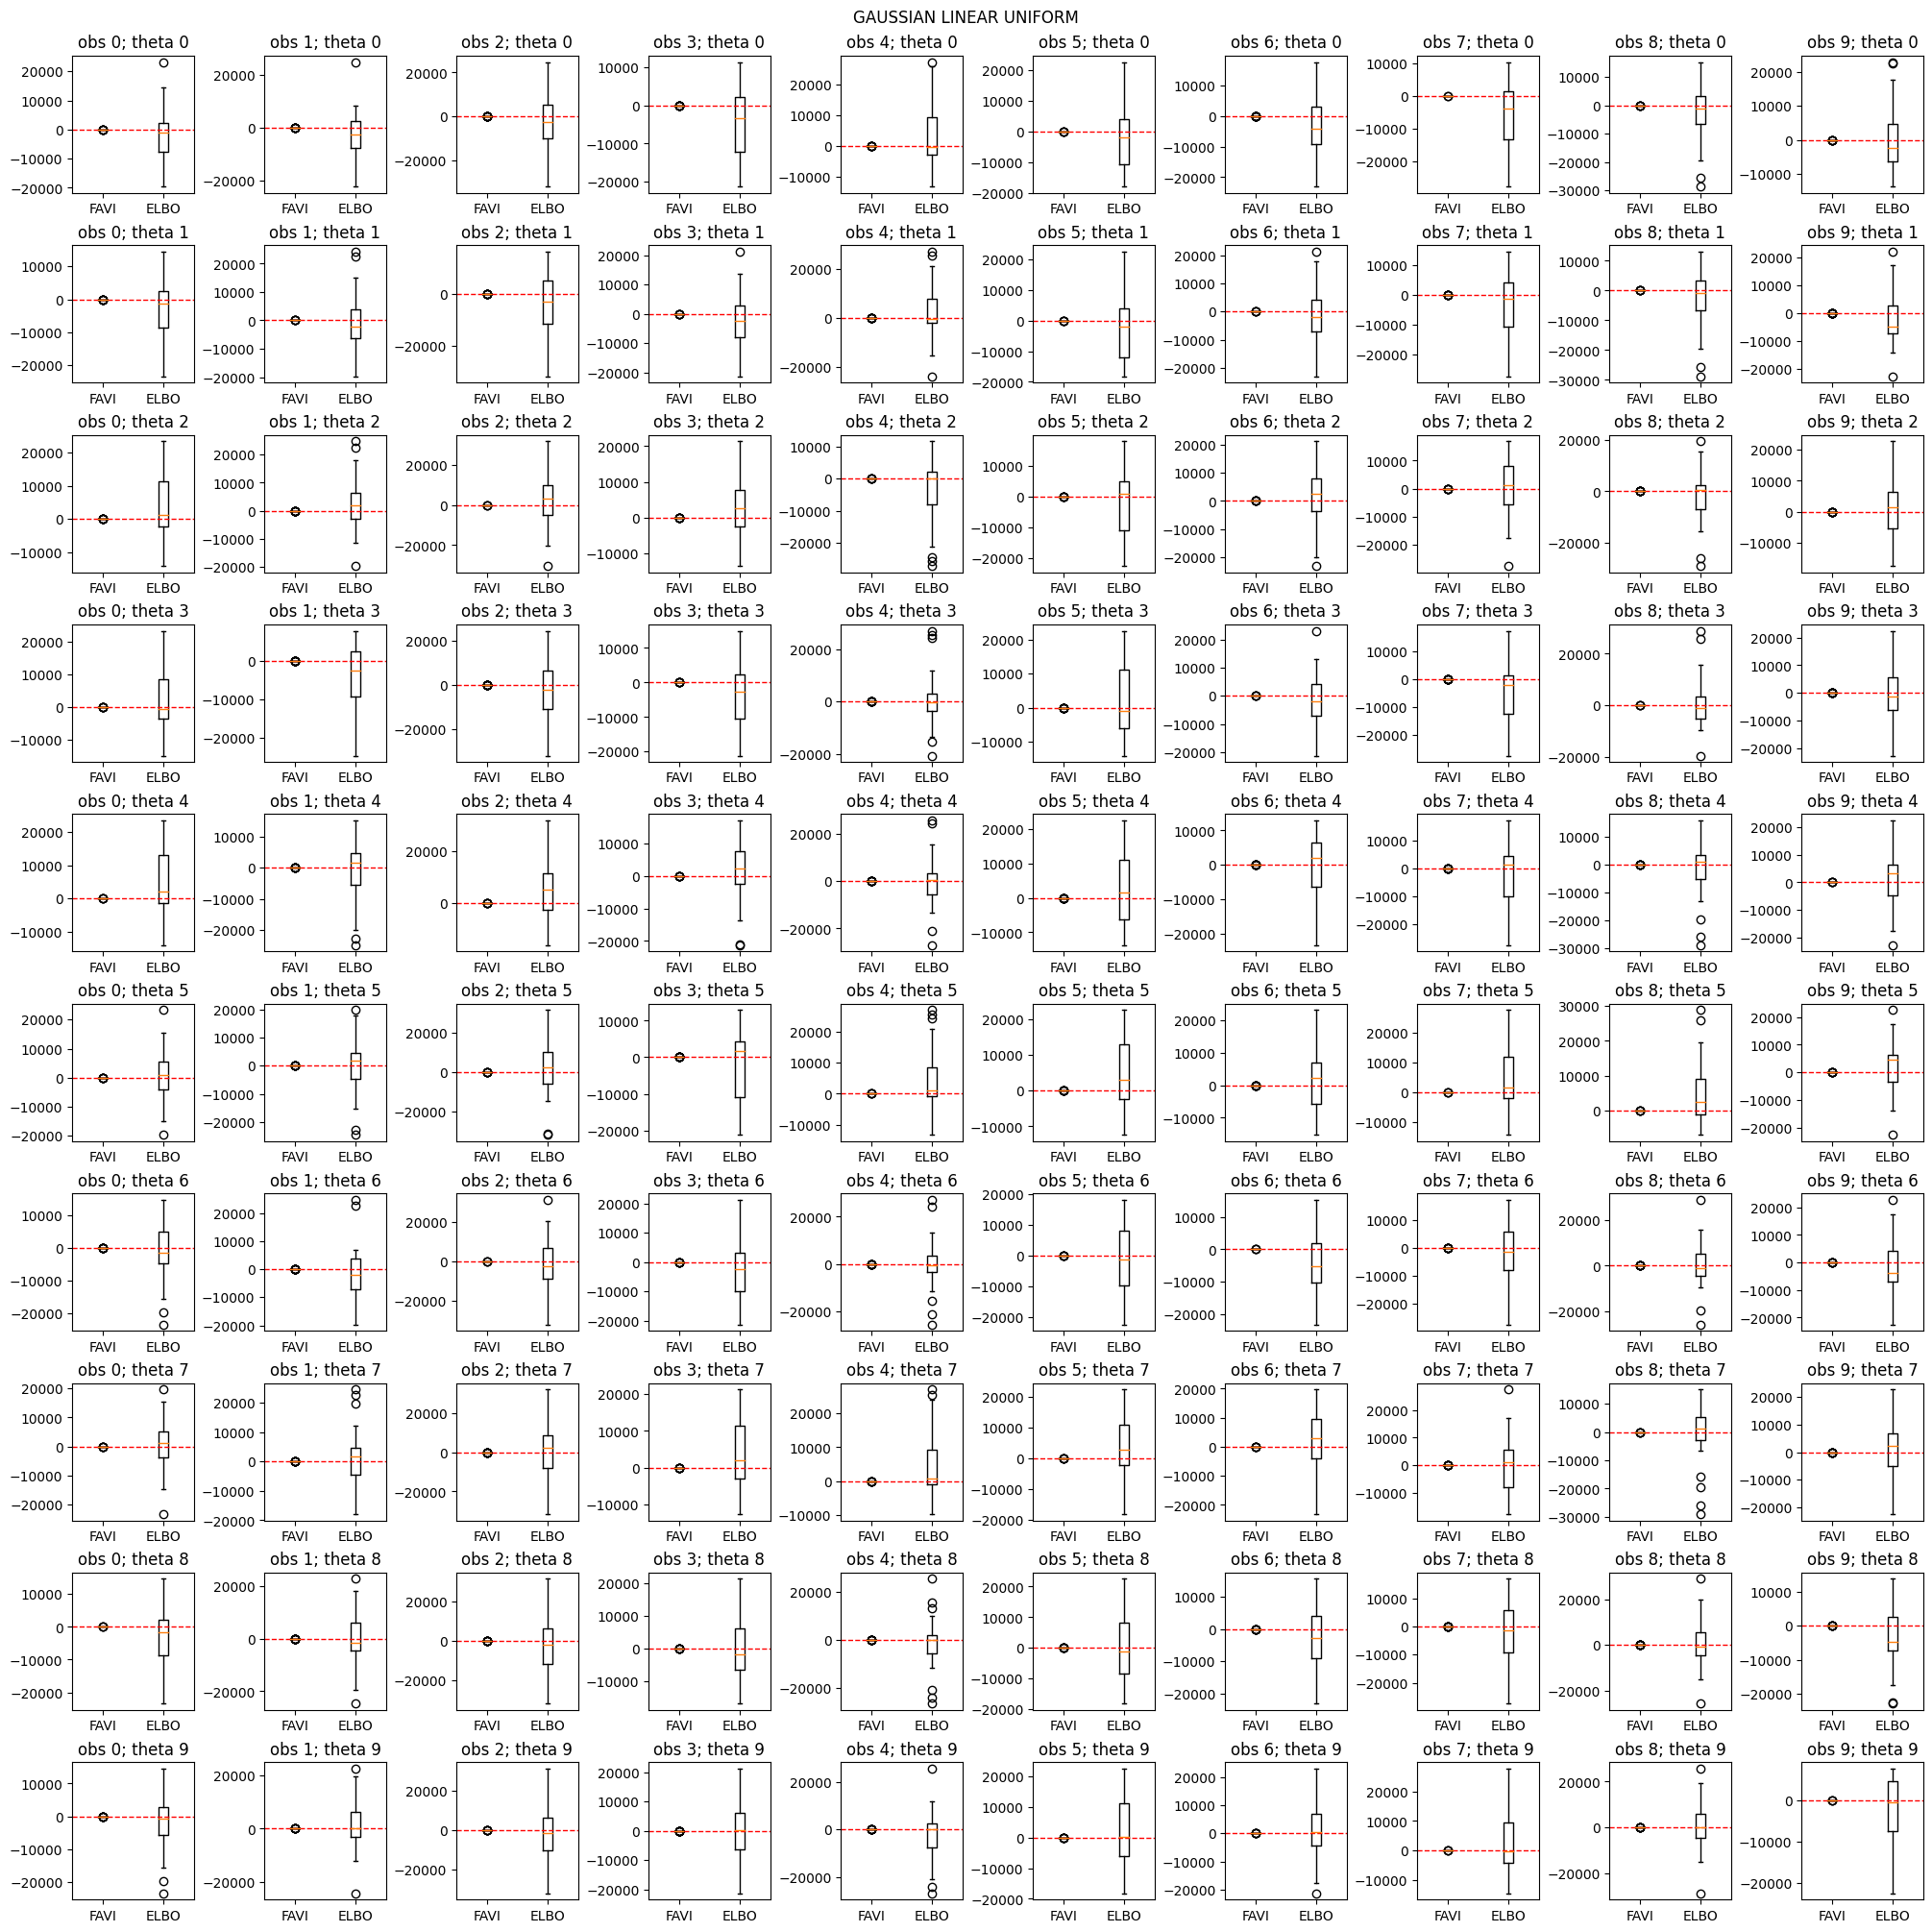

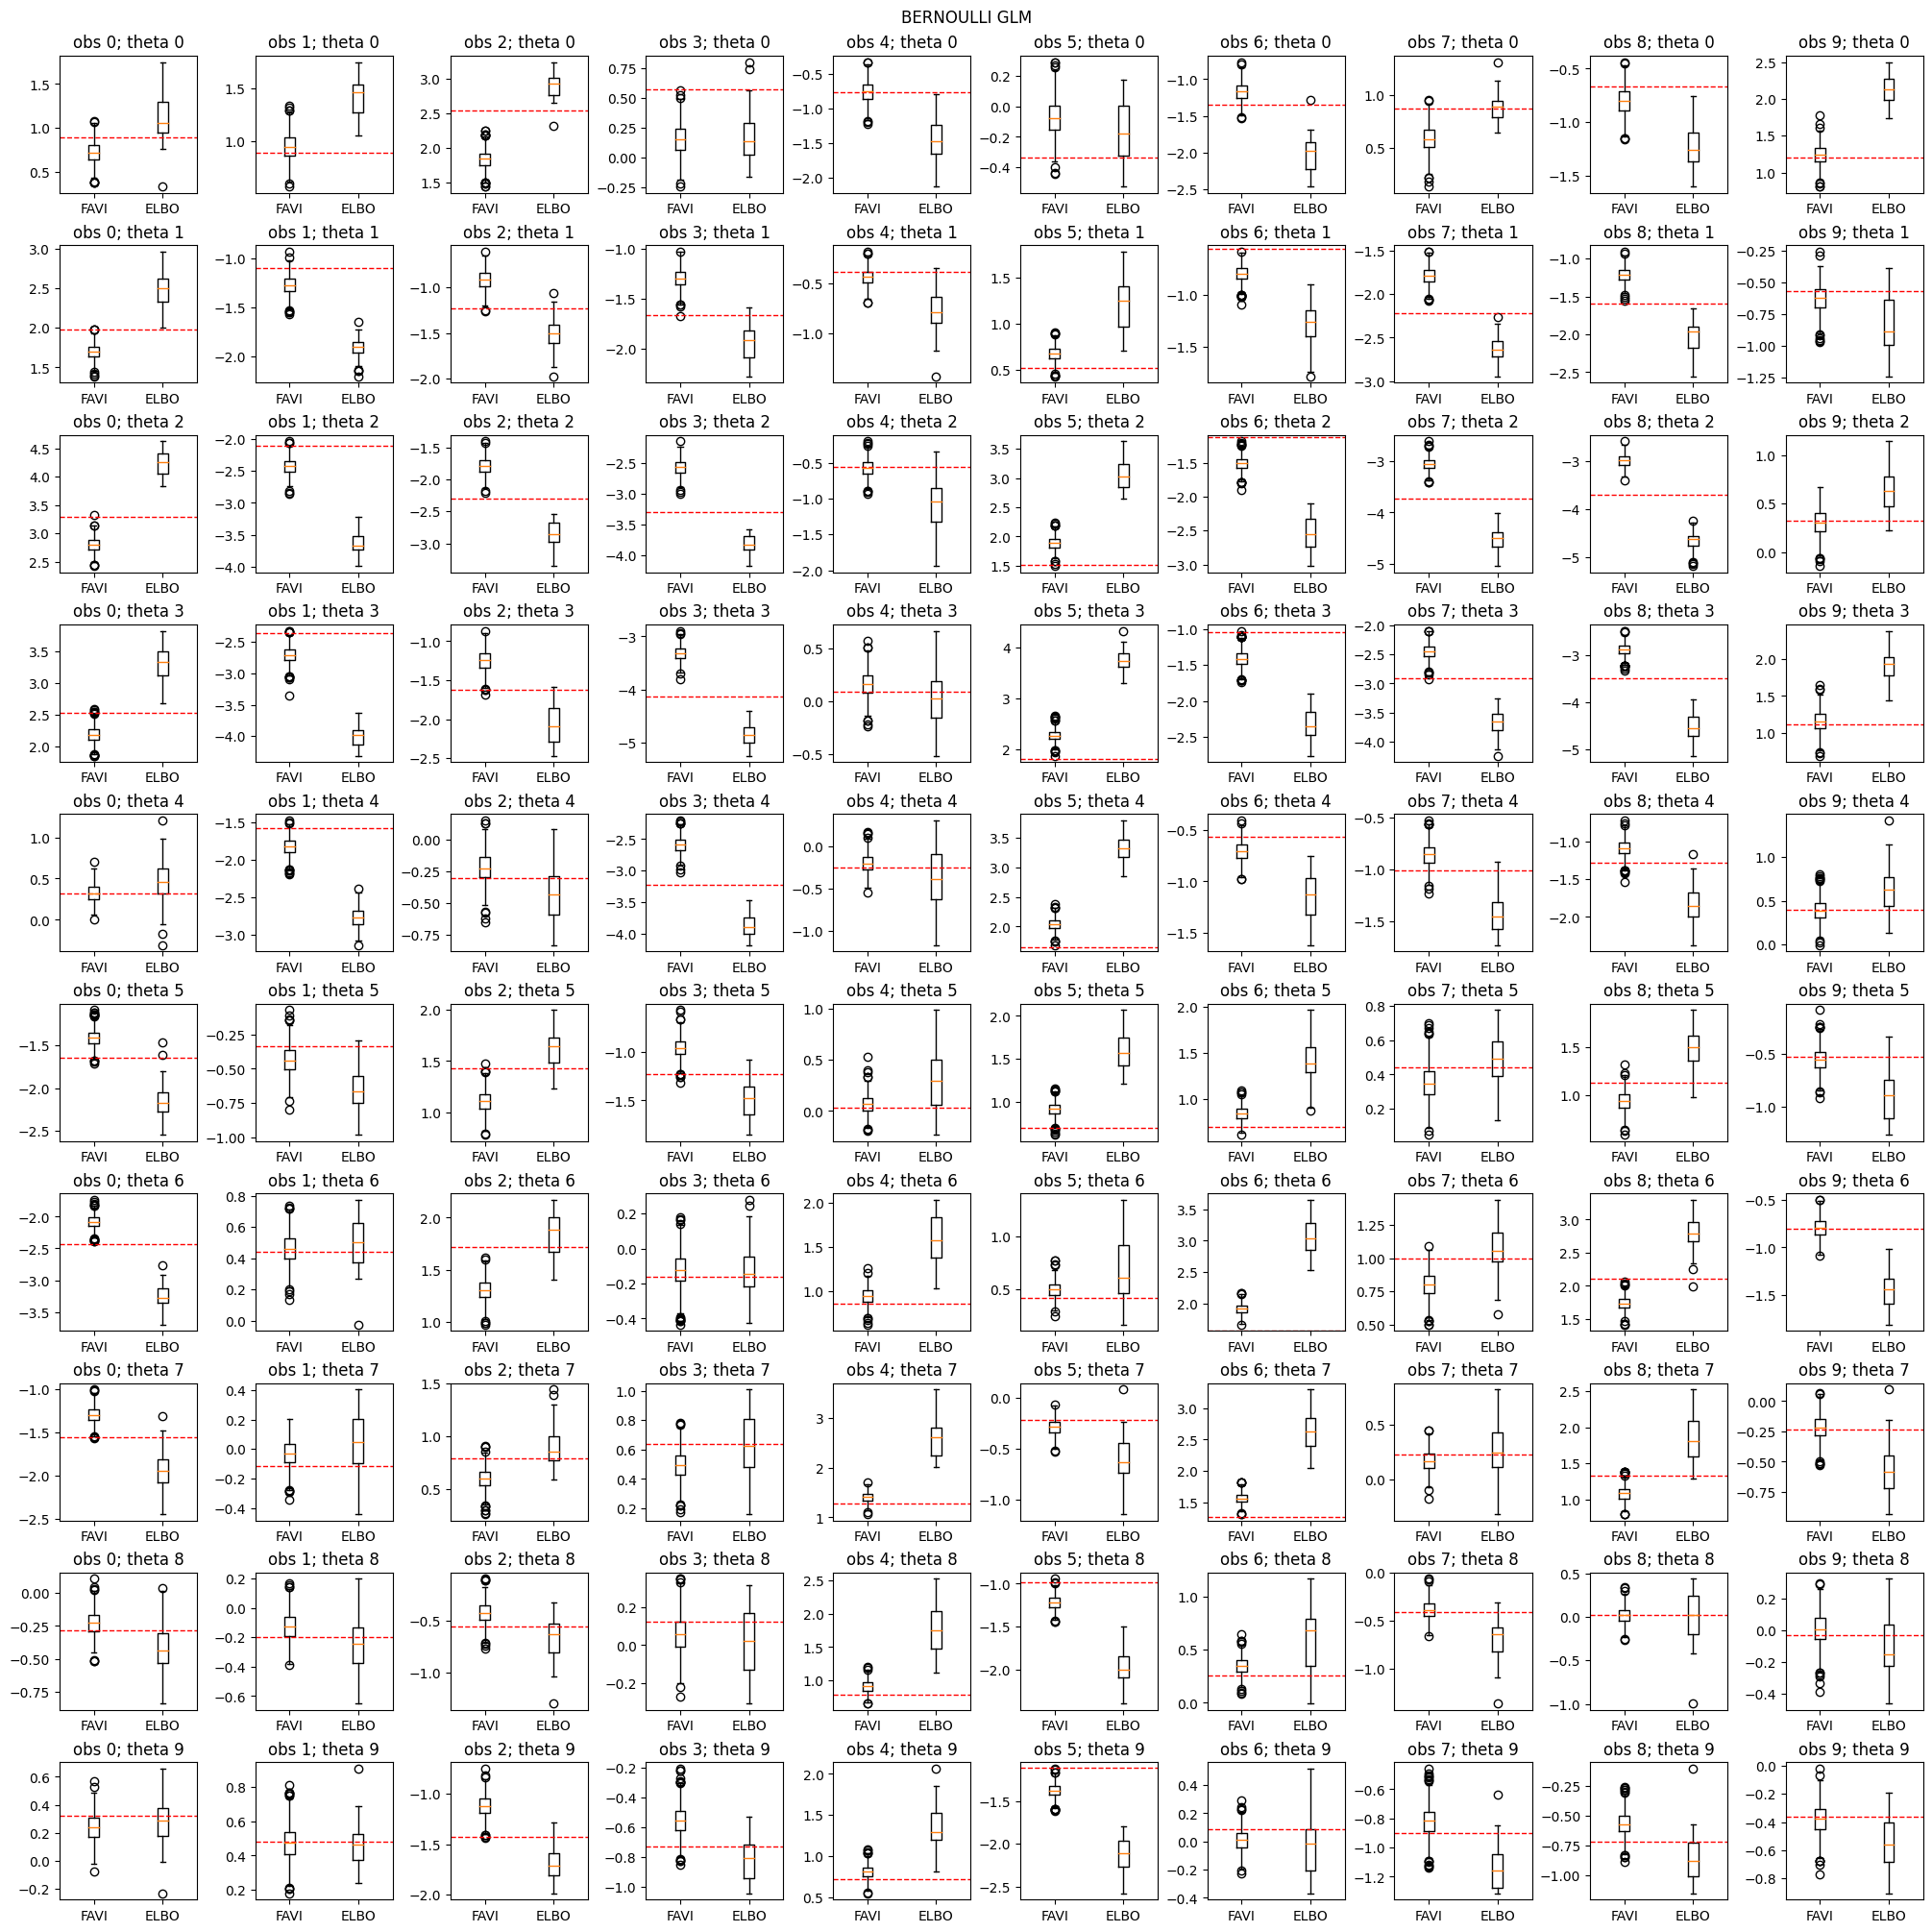

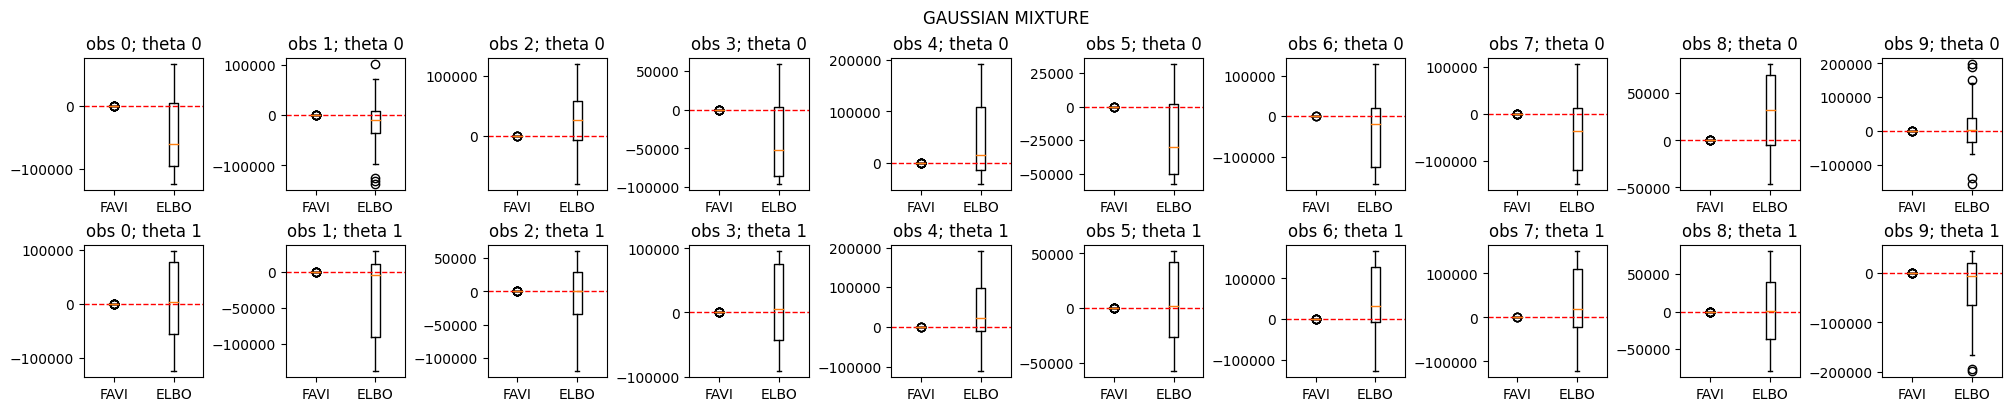

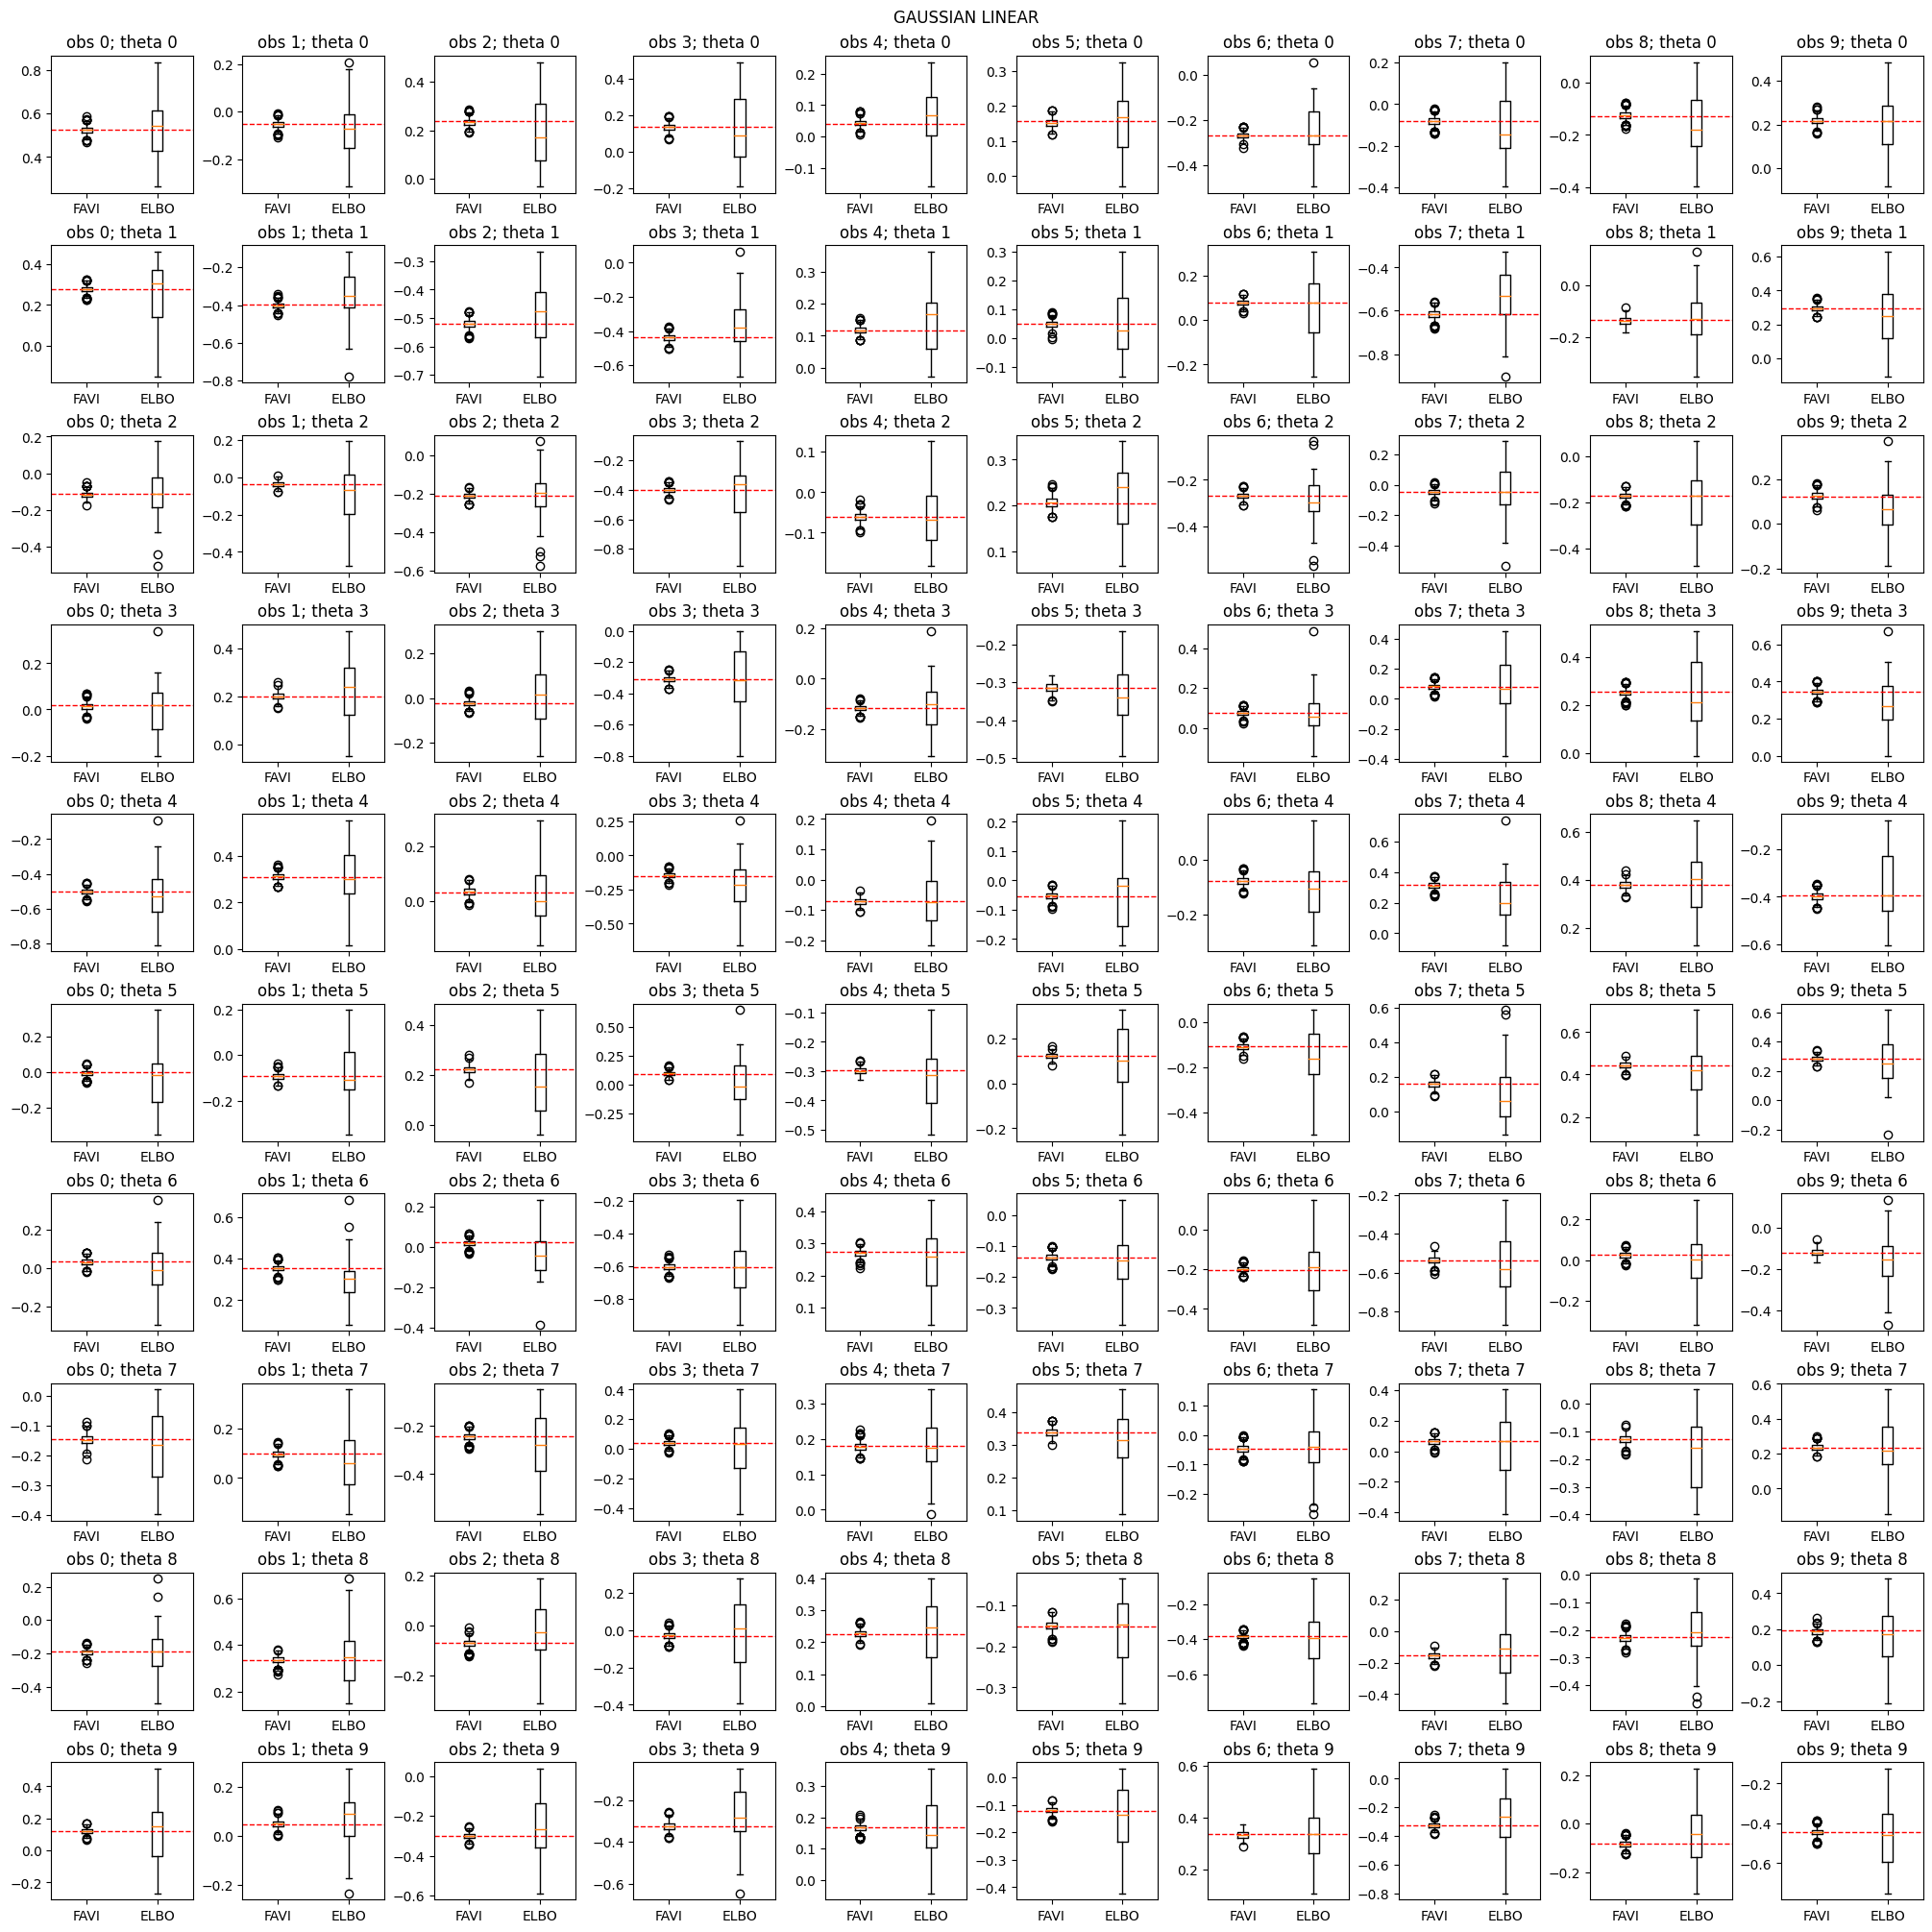

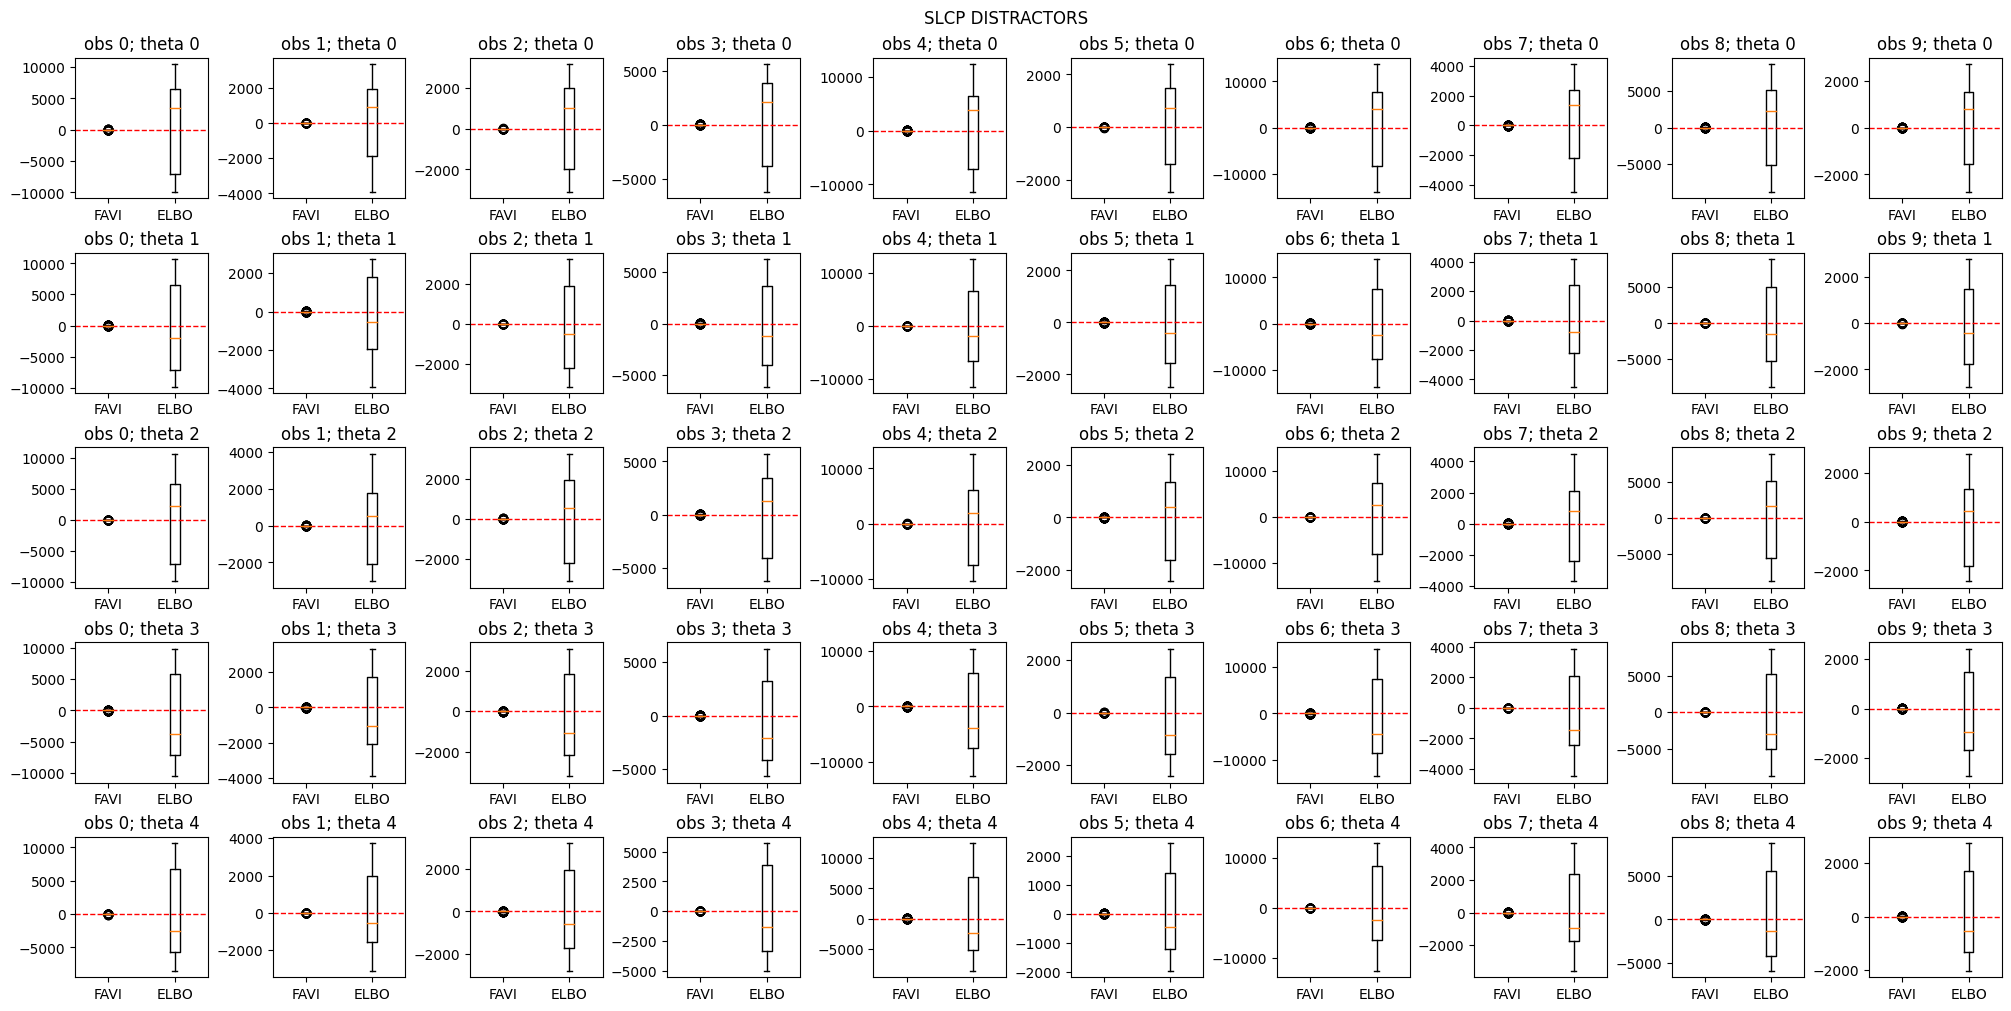

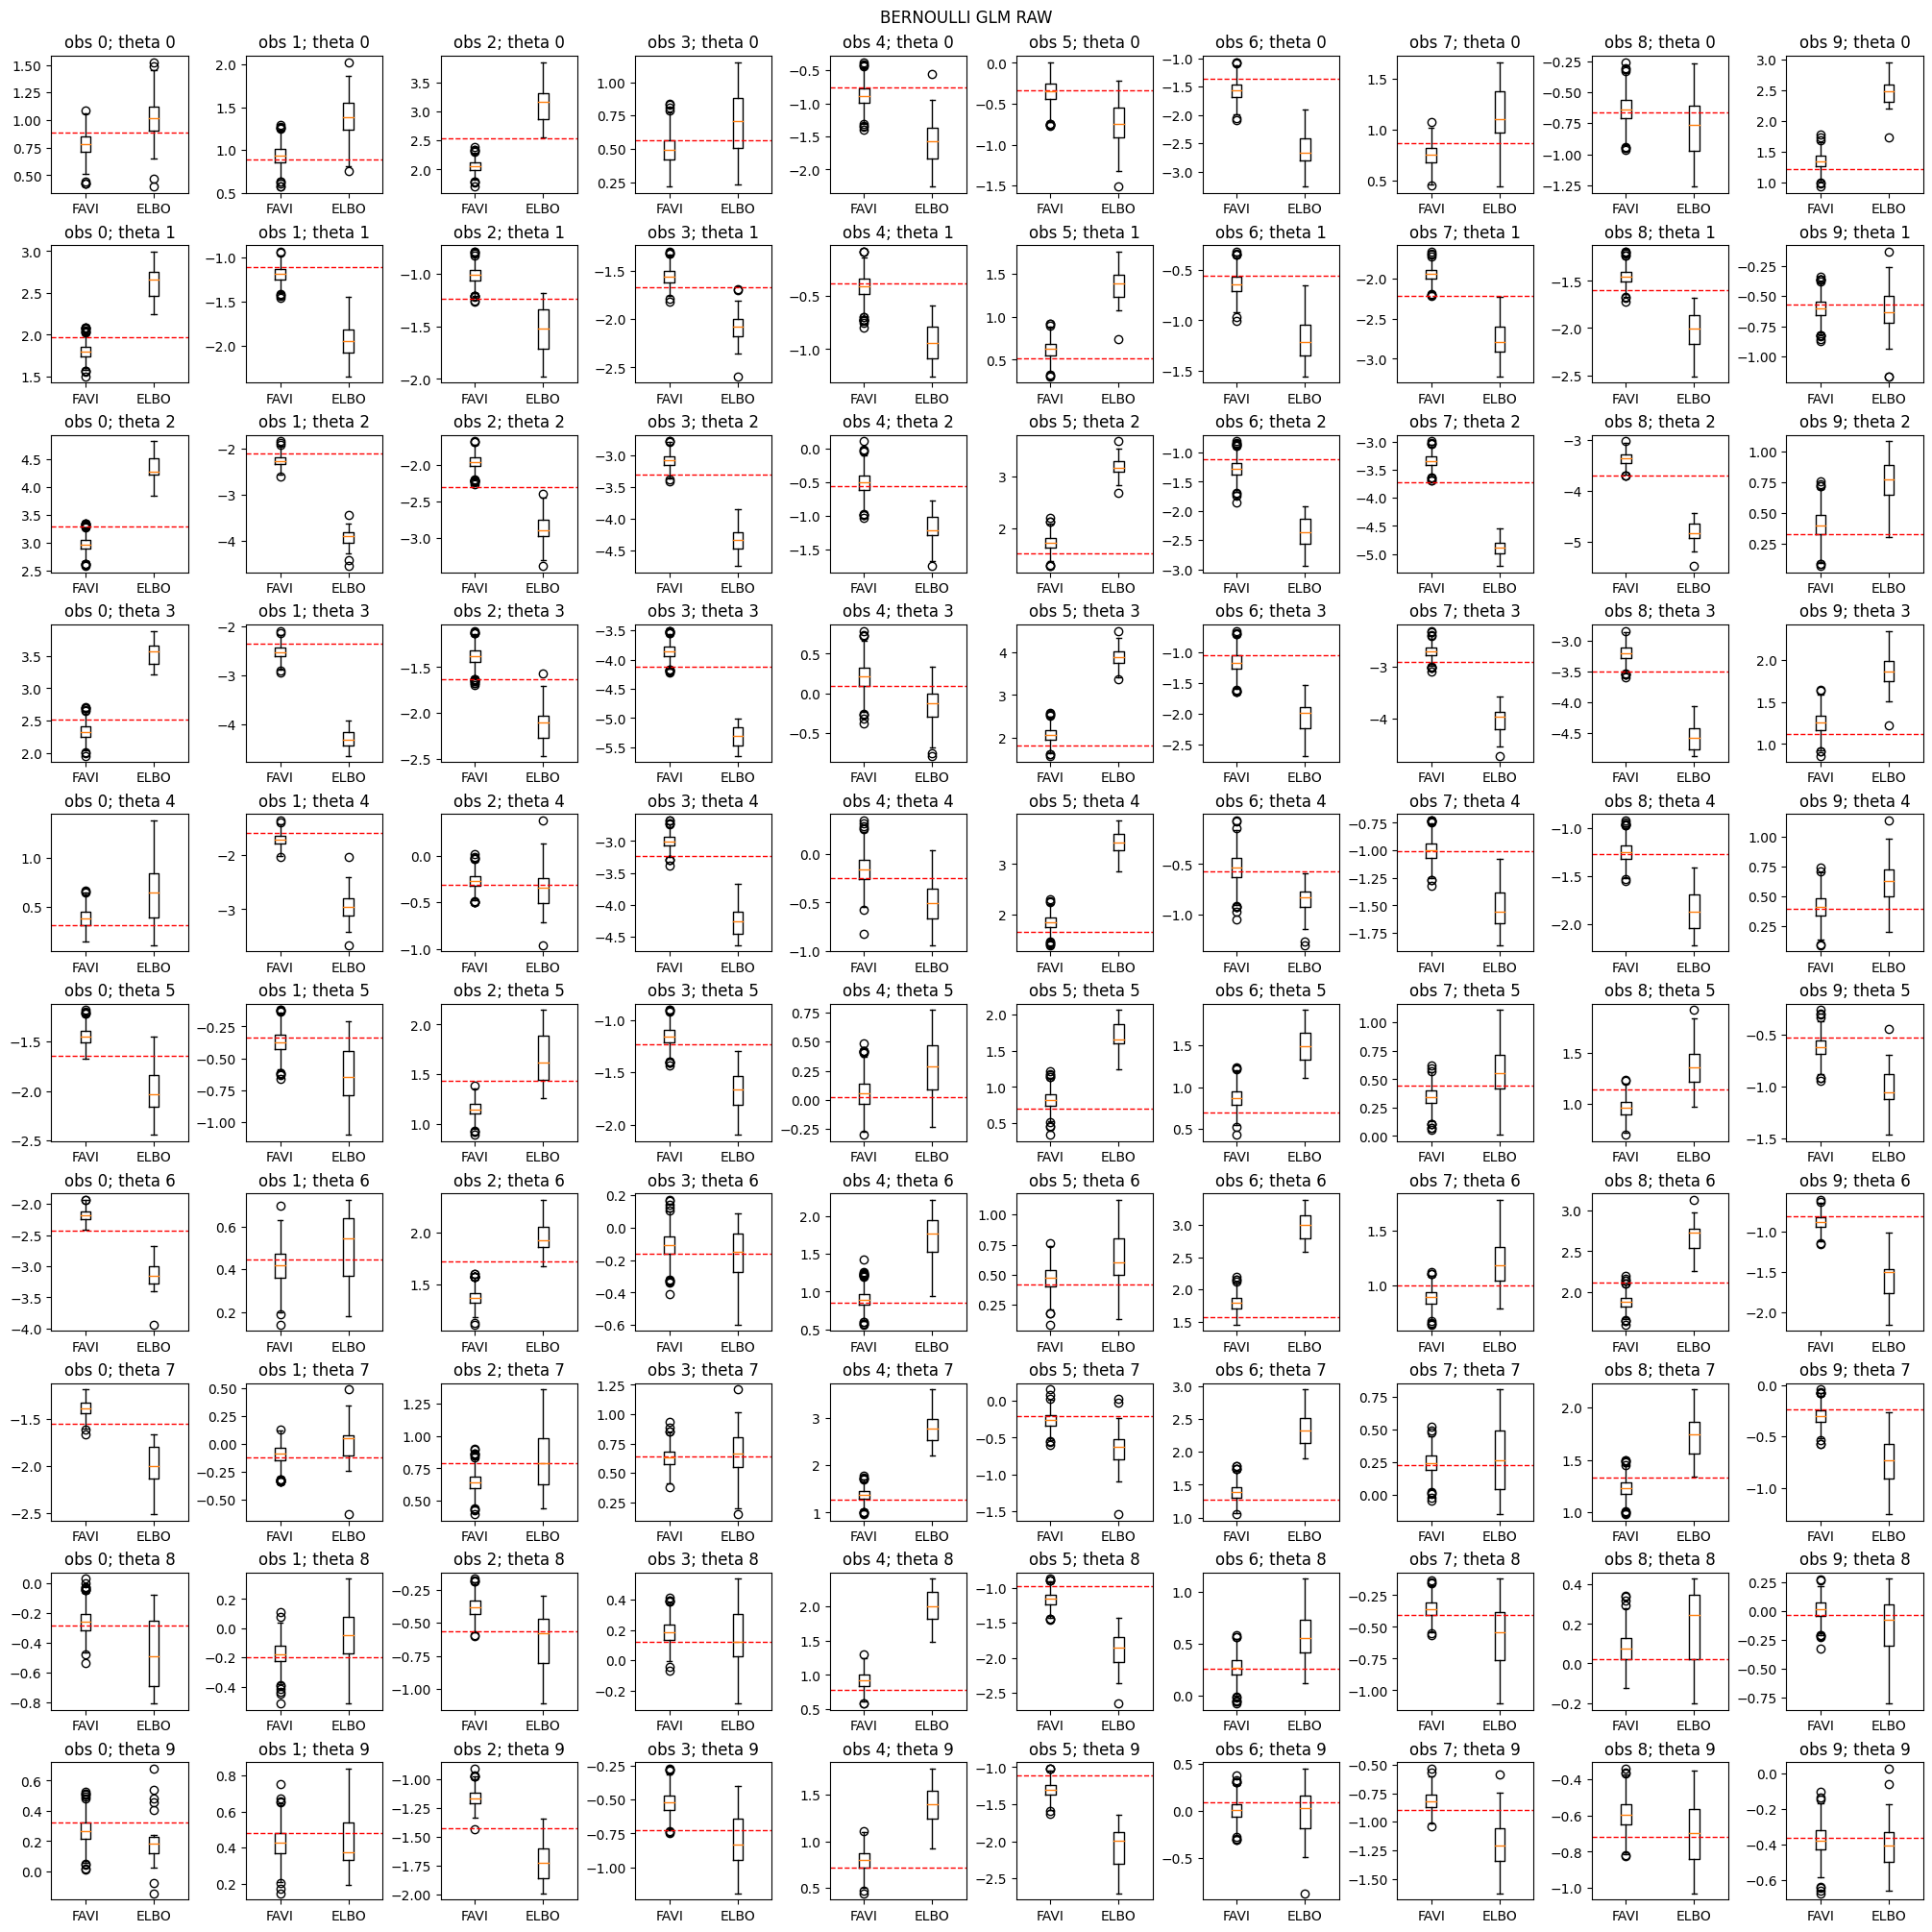

In [6]:
for t in task_list:
    plot_data(f"/data/scratch/pduan/gcvi_output/{t}_1000.pt",
              elbo_data_path=f"/data/scratch/pduan/gcvi_output/elbo_{t}_30.pt")

In [7]:
two_moons_results = torch.load("/data/scratch/pduan/gcvi_output/two_moons_1000.pt")

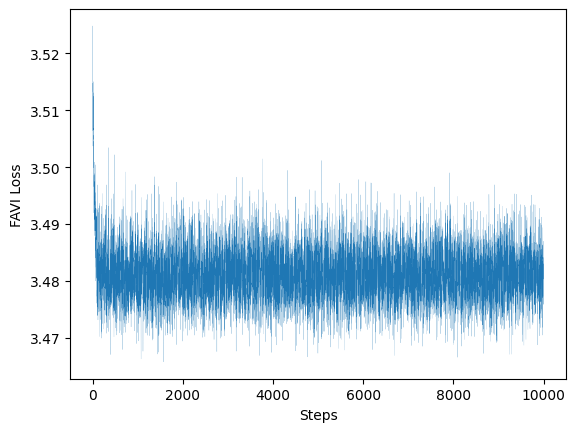

In [8]:
plt.plot(two_moons_results[0]["training_loss"], linewidth=0.1)
plt.xlabel("Steps")
plt.ylabel("FAVI Loss")
plt.show()